pip install xgboost -U

# 多數決演算法(VotingClassifier)測試

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
## 載入資料集
X, y = datasets.load_breast_cancer(return_X_y=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [4]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_std, y_train)
print(f"{gnb.score(X_test_std,y_test):.2f}")

0.93


In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
estimators = [("svc",SVC()),("rf",RandomForestClassifier()),("gnb",GaussianNB())]
clf = VotingClassifier(estimators)
clf.fit(X_train_std,y_train)
print(f"{clf.score(X_test_std,y_test):.2f}")

0.96


## 強化法(Boosting)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

from sklearn.datasets import load_digits

In [9]:
dataset = load_digits()
X = dataset["data"]
y = dataset["target"]

4


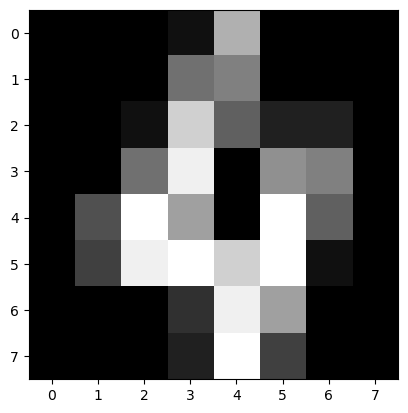

In [10]:
plt.imshow(X[4].reshape(8,8),cmap="gray")
print(y[4])

In [11]:
clf = DecisionTreeClassifier(max_depth = 10)
score_dc =  cross_val_score(clf, X, y, cv=5)
score_dc.mean()

np.float64(0.7880114515629836)

## AdaBoost模型評估

SAMME

的基本思想是通過多次迭代訓練分類器，每次迭代中調整樣本權重，使得錯誤分類的樣本在後續迭代中具有更大的權重，從而加強對這些錯誤樣本的學習。

In [16]:
clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=10),  n_estimators=50,
    learning_rate=1.0,
    random_state=42)

score_dc =  cross_val_score(clf, X, y, cv=5)
score_dc.mean()

np.float64(0.9454828226555246)

# XGBoost測試

In [17]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [18]:
california = pd.read_csv("./california_housing_dataset.csv")
X = california.drop(["Target"],axis=1)
y = california["Target"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(mean_squared_error(y_pred,y_test))

0.2225899267544737


In [21]:
## 使用分類模型
from xgboost import XGBClassifier
X,y = datasets.load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
model = XGBClassifier()
model.fit(X_train,y_train)
score = cross_val_score(model,X_test,y_test,cv=10)
print(score.mean())

0.9196969696969697


## Kmeans

In [22]:
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [23]:
import numpy as np
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=150,
                 n_features=2,
                 centers=3,
                 cluster_std=0.5,
                 shuffle=True,
                 random_state=0)
# 150筆資料 2個特徵 分成3群 標準差0.5 是否重新洗牌shuffle

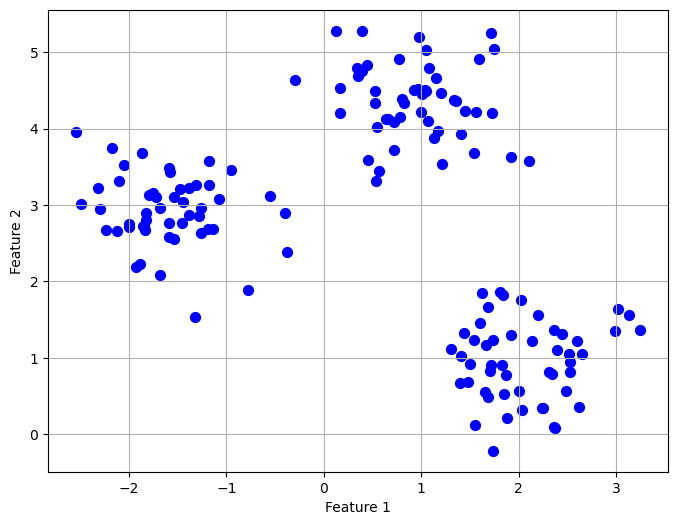

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c="blue",marker="o",s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [32]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2,init="k-means++",random_state=0,max_iter=100)

y_km = km.fit_predict(X)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


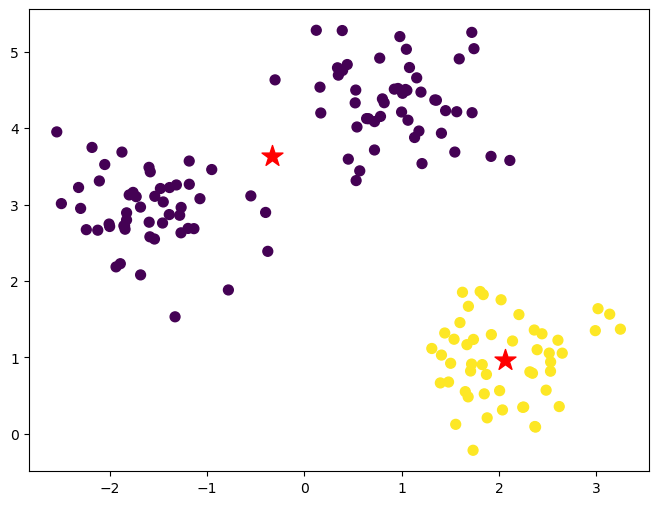

In [33]:

plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y_km,marker="o",s=50,cmap="viridis")
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],s=250,marker="*",c="red",label="centers")

In [ ]:
#km.inertia_ 所有點到它們所屬群中心的距離平方總和（Sum of Squared Distances, SSD）
#Inertia 越小越好
km.inertia_

283.46101780209307

In [29]:
distortions = []
for i in range(1,11):
    km = KMeans(n_clusters=i,init="k-means++",random_state=0,max_iter=300)
    km.fit(X)
    distortions.append(km.inertia_)
for i in range(len(distortions)):    
    print(i+1,distortions[i])


1 713.6998289434159
2 283.46101780209307
3 72.47601670996698
4 67.30934494757155
5 58.65546094894906
6 51.37648198195417
7 41.87680035829947
8 35.98988395951002
9 33.514211339645755
10 29.50793550053656


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

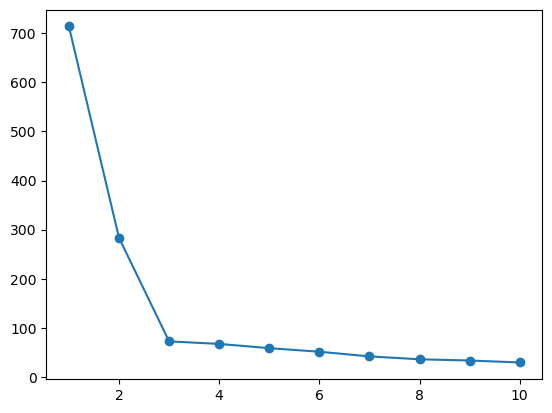

In [34]:
plt.plot(range(1,11),distortions,marker="o")

## silhouette_score 輪廓係數
它在看：同一群是不是夠近、不同群是不是夠遠

分數範圍：

-1 ~ 1

越接近 1 → 分群越好

接近 0 → 分群很模糊

負數 → 分得很爛


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
#最多只用 1 個 CPU 執行緒 去跑平行運算。
os.environ['OMP_NUM_THREADS'] = '1'

In [36]:
import numpy as np
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=150, 
                  n_features=2, 
                  centers=3, 
                  cluster_std=0.5, 
                  shuffle=True, 
                  random_state=0)

In [39]:
scoreList = []
for k in range(2,10):
    km = KMeans(n_clusters=k,init="k-means++",random_state=0,max_iter=300)
    y_km = km.fit_predict(X)
    score = silhouette_score(X,y_km)
    scoreList.append((k,score))
scoreList.sort(key=lambda x:x[1],reverse=True)    
for k,s in scoreList:
    print(k,s)

3 0.7143417887288687
2 0.5848706144251782
4 0.5640802327362099
6 0.45769318506163664
5 0.4367927467614468
8 0.33747598854695504
9 0.3313319318964229
7 0.32656382253649174


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

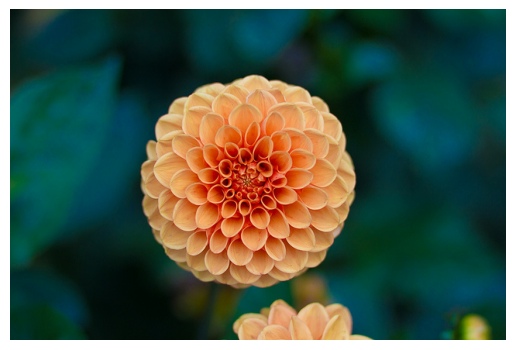

In [2]:
flower = load_sample_image("flower.jpg")
plt.axis("off")
plt.imshow(flower)

## 正規化、取得圖片寬高及顏色維度、將寬高轉為一維

In [3]:
# 正規化
flower = np.array(flower, dtype=np.float64) / 255

# 取得圖片寬高及顏色維度
w, h, d = tuple(flower.shape)

# 將寬高轉為一維
image_array = np.reshape(flower, (w * h, d))
w, h, d,image_array.shape


(427, 640, 3, (273280, 3))

In [5]:
image_sample = shuffle(image_array, random_state=42)[:2000]


In [15]:
kmeans = KMeans(n_clusters=128, random_state=42).fit(image_sample)


In [13]:
#labels[labels_index] 群的id
#centers質心的位置 代表真的顏色
def reconstruct_image(centers,labels,w,h):
    d = centers.shape[1]
    image = np.zeros((w,h,d))
    labels_index = 0
    for i in range(w):
        for j in range(h):
            image[i][j] = centers[labels[labels_index]]
            labels_index += 1
    return image    

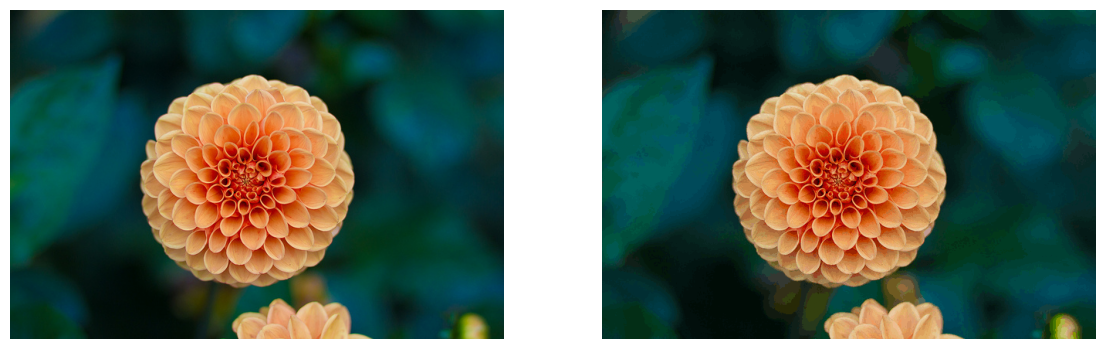

In [16]:
labels = kmeans.predict(image_array)
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.axis("off")
plt.imshow(flower)
plt.subplot(1,2,2)
plt.axis("off")
plt.imshow(reconstruct_image(kmeans.cluster_centers_,labels,w,h))


## DBSCAN

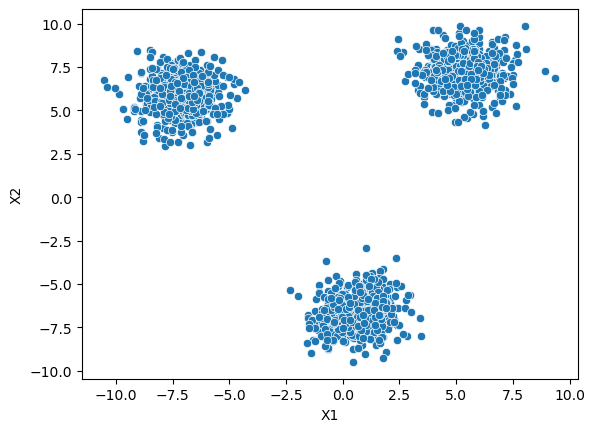

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

blobs = pd.read_csv("./cluster_blobs.csv")
blobs.head()
sns.scatterplot(x="X1",y="X2",data=blobs)
plt.show()

In [18]:
moons = pd.read_csv("./cluster_moons.csv")
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


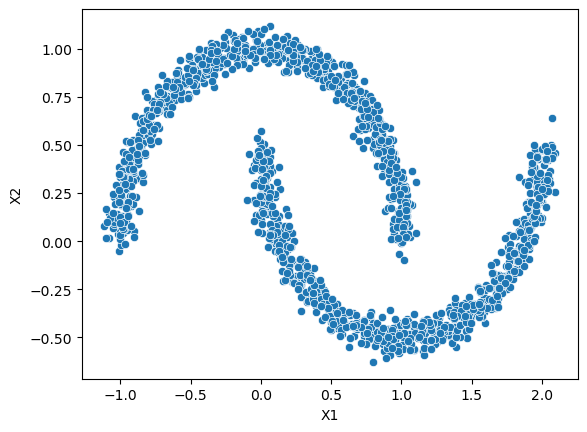

In [19]:
sns.scatterplot(x="X1",y="X2",data=moons)
plt.show()

In [20]:
circles = pd.read_csv("./cluster_circles.csv")
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


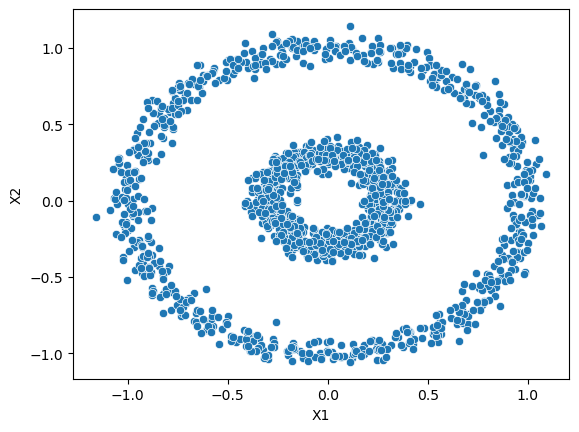

In [21]:
sns.scatterplot(x="X1",y="X2",data=circles)
plt.show()

## 用於顯示群集的散佈圖

In [23]:
def diaplay_mode(model,data):
    labels = model.fit_predict(data)
    sns.scatterplot(x="X1",y="X2",hue=labels,data=data)
    plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


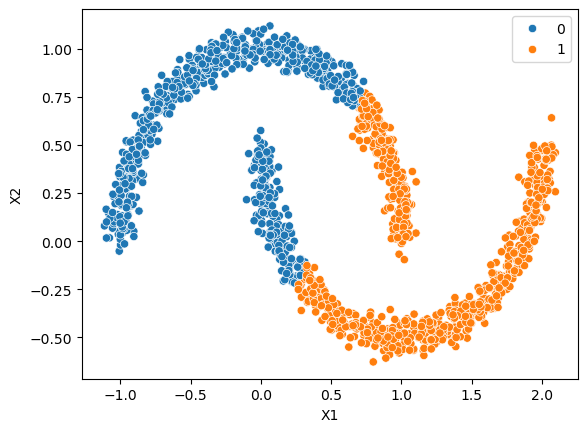

In [24]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2,init="k-means++",n_init="auto")
diaplay_mode(model,moons)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


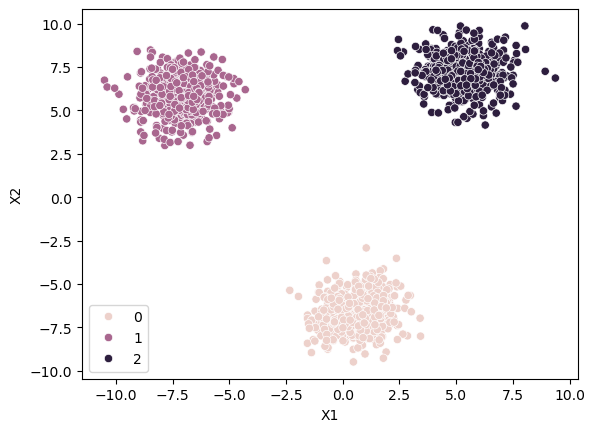

In [26]:
model = KMeans(n_clusters=3,init="k-means++",n_init="auto")
diaplay_mode(model,blobs)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


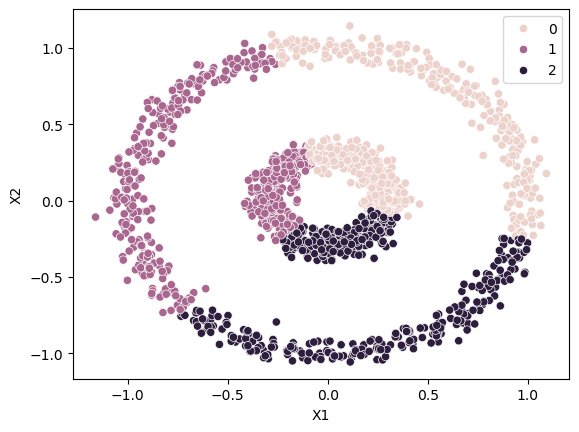

In [27]:
model = KMeans(n_clusters=3,init="k-means++",n_init="auto")
diaplay_mode(model,circles)

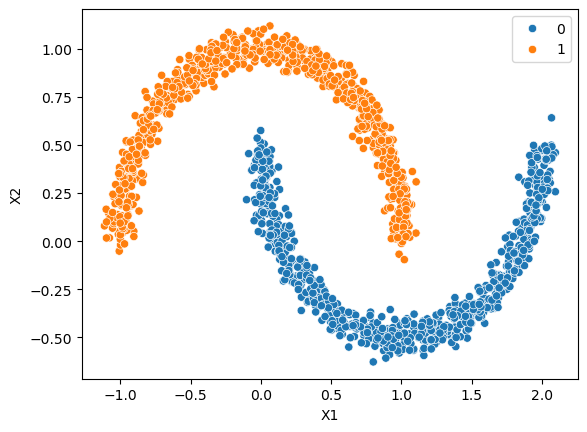

In [28]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.2)
diaplay_mode(model,moons)

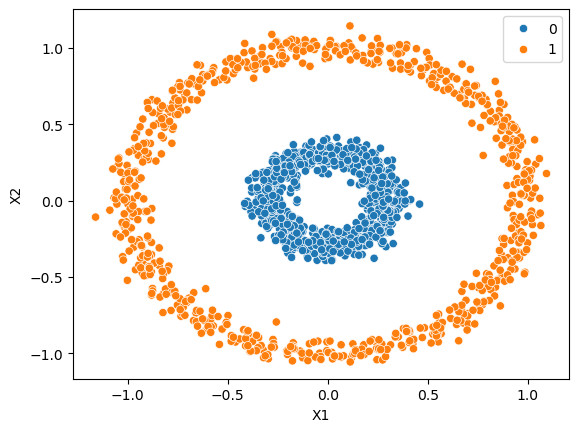

In [29]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.2)
diaplay_mode(model,circles)

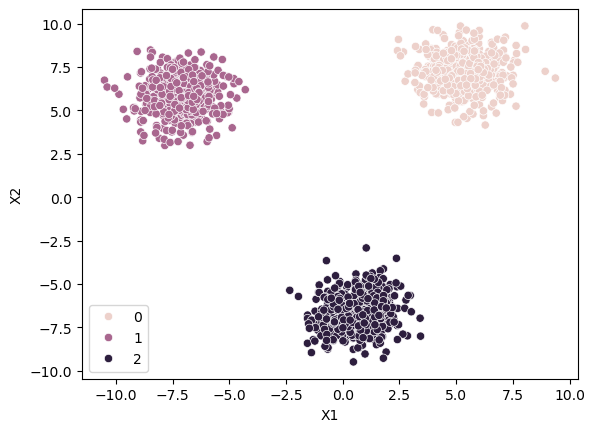

In [34]:
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=1.5)
diaplay_mode(model,blobs)

In [33]:
from sklearn.metrics import silhouette_score #輪廓係數
from sklearn.cluster import DBSCAN
import numpy as np
silhouette_scores = []
#silhouette_score 越大越好。
data = blobs
eps_values = np.arange(0.1,3.0,0.1)
for eps in eps_values:
    testModel = DBSCAN(eps= eps)
    y_km = testModel.fit_predict(data)
    if len(set(y_km)) > 1:#set過濾重複 至少要1個以上
        silhouette_scores.append(silhouette_score(data,y_km))
    else:
        silhouette_scores.append(-1) 

bast_index = np.argmax(silhouette_scores)        
bast_eps = eps_values[bast_index]
bast_score = silhouette_scores[bast_index]
print(f"eps:{bast_eps} bast_score:{bast_score}")

eps:1.5000000000000002 bast_score:0.8625486425630479


# 半監督式學習
# 自我訓練(Self-training)測試

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier

In [36]:
X,y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=0)

In [37]:
## 設定 約50% 資料為沒有標註(-1)
print(X_train.shape,y_train.shape)
rng = np.random.RandomState(42)
y_rand =  rng.rand(y_train.shape[0])
print(len(y_rand))

(120, 4) (120,)
120


In [39]:
y_50 = np.copy(y_train)
y_50[y_rand < 0.5] = -1#讓約50%的資料為-1為了移除標籤y
print(len(y_50[y_50==-1]))
print(len(y_train))

62
120


In [40]:
base_class = SVC(kernel="rbf",gamma=0.5)
base_class.fit(X_train,y_50)
base_class.score(X_test,y_test)

0.43333333333333335

In [42]:
base_class = SVC(kernel="rbf",gamma=0.5,probability=True)
clf = SelfTrainingClassifier(base_class).fit(X_train,y_50)
clf.score(X_test,y_test)

1.0